# 44 - Measuring Computation Time

**Section:** Model Evaluation | **Prereqs:** `Model Evaluation/ARPF_WineDataset.ipynb` | **Next:** `Model Evaluation/ARPF_MNIST.ipynb`

Accuracy is not the only axis a model is judged on. Training time decides how many
experiments you can run in a day, and inference time decides whether the model can
ship.

**Three ways to time things in a notebook**
- `time.process_time()` - CPU time used by this process. Ignores time spent
  waiting, which makes it a fair measure of compute but a poor measure of
  wall-clock duration.
- `time.perf_counter()` - wall-clock elapsed time. Usually what you want.
- `%%time` / `%%timeit` cell magics, or the `autotime` extension used here, which
  prints the duration of every cell automatically.

**On a GPU, all three lie by default.** CUDA calls are asynchronous: Python
returns before the GPU has finished, so a naive timer measures how long it took to
*queue* the work. Call `torch.cuda.synchronize()` immediately before reading the
clock, or use `torch.cuda.Event`.

**What to time:** the whole training run for planning, one forward pass for
deployment, and the data pipeline separately - a surprising number of 'slow
models' are actually starved DataLoaders.

In [16]:
# ipython-autotime prints the run time under every cell automatically.
# Convenient for a quick survey, noisy in a finished notebook - which is the
# trade-off noted in the inline comment.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset,DataLoader

from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST
import time

!pip install ipython-autotime
%load_ext autotime  # This library can be used to moniter time, only downside will display time for all cells.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.7 MB/s eta 0:00:00
time: 261 µs (started: 2025-08-27 19:15:05 +00:00)


In [17]:
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

time: 82 ms (started: 2025-08-27 19:15:05 +00:00)


In [18]:
# The usual MNIST pipeline: scale, split into train/dev, tensors on GPU, loaders.
def makeDataset():

  data_tensor = data.data.view(-1, 784)
  labels_tensor = data.targets


  from sklearn.preprocessing import MinMaxScaler

  scaler = MinMaxScaler()

  data_subset = scaler.fit_transform(data_tensor)


  from sklearn.model_selection import train_test_split

  train_data, dev_data , train_label, dev_label = train_test_split(data_subset, labels_tensor, test_size=0.2, shuffle=True)

  train_data = torch.tensor(train_data, dtype=torch.float, device='cuda')
  train_label = torch.tensor(train_label, dtype=torch.long, device='cuda')


  dev_data = torch.tensor(dev_data, dtype=torch.float, device='cuda')
  dev_label = torch.tensor(dev_label, dtype=torch.long, device='cuda')

  train_tensor = TensorDataset(train_data, train_label)
  dev_tensor = TensorDataset(dev_data,dev_label)

  bs = 32
  data_loader = DataLoader(train_tensor, batch_size=bs, drop_last=True, shuffle=True)
  test_loader = DataLoader(dev_tensor, batch_size=dev_tensor.tensors[0].shape[0])


  return data_loader, test_loader

time: 1.18 ms (started: 2025-08-27 19:15:07 +00:00)


In [19]:
data_loader, test_loader = makeDataset()

time: 748 ms (started: 2025-08-27 19:15:11 +00:00)


/tmp/ipython-input-1794242417.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_label = torch.tensor(train_label, dtype=torch.long, device='cuda')
/tmp/ipython-input-1794242417.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dev_label = torch.tensor(dev_label, dtype=torch.long, device='cuda')


In [20]:
# A small classifier - 784-64-32-16-10 - so the timing is dominated by the loop
# and data movement rather than by one huge matmul.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784, 64)

    self.fc1 = nn.Linear(64,32)

    self.fc2 = nn.Linear(32,16)

    self.output_layer = nn.Linear(16,10)


  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    x = F.relu(self.fc2(x))

    return self.output_layer(x)

time: 887 µs (started: 2025-08-27 19:15:15 +00:00)


In [23]:
# time.process_time() measures CPU time consumed by this process, so it excludes
# time spent waiting on I/O - and, importantly, time spent waiting on the GPU.
# For GPU work call torch.cuda.synchronize() before reading the clock, otherwise
# you are timing how fast Python queued the kernels, not how long they ran.
def train_model():


  pre_traintime = time.process_time() # This tell the current cpu time in seconds
  classifier = model().to('cuda')

  epochs = 10
  lr = 0.01

  lossFunc = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(classifier.parameters(), lr=lr)

  train_acc = []
  dev_acc = []
  losses = torch.zeros(epochs)


  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []

    for x,y in data_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())


      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean( (torch.argmax(yhat,dim = 1) == y).float()).cpu() )

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    if i % 1 == 0 or i == epochs-1:
      print(f"Sample Size = {data_loader.dataset.tensors[0].shape[0]} |Epoch {i} : Loss = {losses[i].item()}")

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      Preds = torch.argmax(classifier(X), dim = 1)
      dev_acc.append( 100 * torch.mean( (Preds == Y).float()) )

  print(f'Time taken : {time.process_time() - pre_traintime}')
  return losses, train_acc, dev_acc, classifier


time: 1.94 ms (started: 2025-08-27 19:15:37 +00:00)


In [24]:
# Train and print the elapsed time.

losses, train_acc, dev_acc, classifier = train_model()


Sample Size = 48000 |Epoch 0 : Loss = 2.019946336746216
Sample Size = 48000 |Epoch 1 : Loss = 0.6904415488243103
Sample Size = 48000 |Epoch 2 : Loss = 0.4368748664855957
Sample Size = 48000 |Epoch 3 : Loss = 0.35411277413368225
Sample Size = 48000 |Epoch 4 : Loss = 0.30229073762893677
Sample Size = 48000 |Epoch 5 : Loss = 0.2619796395301819
Sample Size = 48000 |Epoch 6 : Loss = 0.22856447100639343
Sample Size = 48000 |Epoch 7 : Loss = 0.2004692703485489
Sample Size = 48000 |Epoch 8 : Loss = 0.17836624383926392
Sample Size = 48000 |Epoch 9 : Loss = 0.16104748845100403
Time taken : 32.60102203399998
time: 33.2 s (started: 2025-08-27 19:15:37 +00:00)


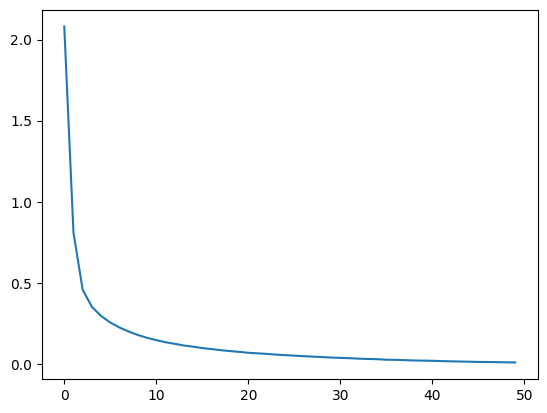

In [11]:
# The loss curve, to confirm the model actually trained and the timing is of a
# real run rather than a broken one.
plt.plot(losses);

# Conclusion: So we can use multiple ways to check how much time did it take a cell to run, we can use the time library in python or there are many differnt ways too, try searching the internet